<a href="https://colab.research.google.com/github/Arati611/ML-Practicals/blob/main/Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64
sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64
sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64


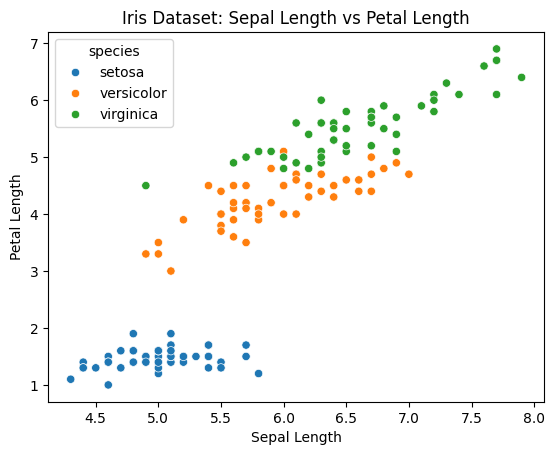

   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0
     sepal_length  sepal_width  petal_length  petal_width  species
145           6.7          3.0           5.2          2.3        2
146           6.3          2.5           5.0          1.9        2
147           6.5          3.0           5.2          2.0        2
148           6.2          3.4           5.4          2.3        2
149           5.9          3.0           5.1          1.8        2


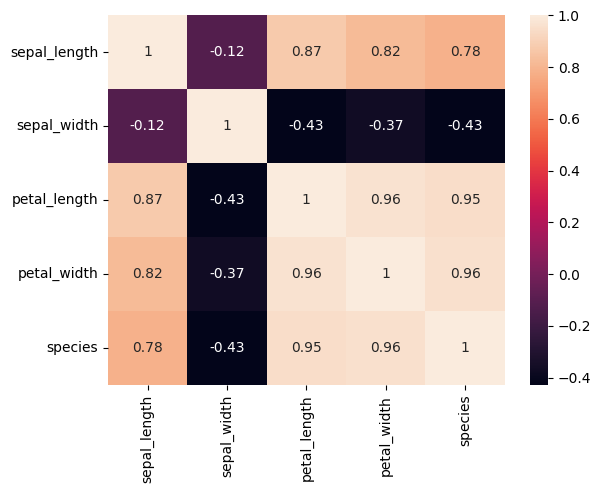

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)
Predicted Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Predicted Class: [0]
Accuracy: 100.0 %
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

iris = sns.load_dataset("iris")
df = pd.DataFrame(iris)
df
df.tail()

print(df.median(numeric_only=True))
print(df.min(numeric_only=True))
print(df.std(numeric_only=True))

sns.scatterplot(data=df, x="sepal_length", y="petal_length", hue="species")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Iris Dataset: Sepal Length vs Petal Length")
plt.show()

le = LabelEncoder()
df["species"] = le.fit_transform(df["species"])
print(df.head())
print(df.tail())

Correlation = df.corr(numeric_only=True)
sns.heatmap(Correlation, annot=True)
plt.show()

X = df.drop("species", axis=1)
y = df["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Predicted Values:")
print(y_pred)

new_data = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_data)
print("Predicted Class:", prediction)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100, "%")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)